In [172]:
import pandas as pd

In [173]:
data = pd.read_csv('/content/heart_disease_messy.csv')

In [174]:
data

,AGE,Cholesterol,max_heart_rate,blood_pressure,Gender,OldPeak,Heart_Disease
0,67,171.6,138.6,116.6,FEMALE,1.69,0
1,57,250.1,197.6,114.4,Female,0.47,0
2,NaN,171.0,NaN,117.6,MALE,NaN,0
3,71,293.4,129.8,147.2,Female,0.21,1
4,36,NaN,105.4,130.4,Male,0.22,0
...,...,...,...,...,...,...,...
2261,69,280.4,81.8,121.4,male,0.64,1
2262,63,NaN,144.6,120.9,Male,2.72,1
2263,71,218.0,142.8,149.4,female,1.63,1
2264,50,199.8,NaN,142.8,Female,3.02,1


In [175]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2266 entries, 0 to 2265
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AGE              2069 non-null   object 
 1   Cholesterol      2084 non-null   float64
 2    max_heart_rate  2083 non-null   float64
 3   blood_pressure   2081 non-null   float64
 4   Gender           2266 non-null   object 
 5   OldPeak          2083 non-null   float64
 6   Heart_Disease    2266 non-null   object 
dtypes: float64(4), object(3)
memory usage: 124.1+ KB


In [176]:
data.columns

Index(['AGE', 'Cholesterol ', ' max_heart_rate', 'blood_pressure', 'Gender',
       'OldPeak', 'Heart_Disease'],
      dtype='object')

In [177]:
data = data.rename(columns={'AGE':'Age','Cholesterol ':'Cholesterol',' max_heart_rate':'Max_Heart_Rate','blood_pressure':'Blood_Pressure','OldPeak':'Old_Peak'})

In [178]:
data.columns

Index(['Age', 'Cholesterol', 'Max_Heart_Rate', 'Blood_Pressure', 'Gender',
       'Old_Peak', 'Heart_Disease'],
      dtype='object')

In [179]:
data.dtypes

,0
Age,object
Cholesterol,float64
Max_Heart_Rate,float64
Blood_Pressure,float64
Gender,object
Old_Peak,float64
Heart_Disease,object


In [180]:
# data['Age'] = data['Age'].astype(int)

In [181]:
# print(data.to_string())

In [182]:
a = data['Age'].unique()
print(a)

['67' '57' nan '71' '36' '49' '47' '51' '39' '52' '64' '68' '31' '50' '30'
 '72' '58' '66' '61' '40' '53' '77' '55' '70' '56' '44' '43' '75' '65'
 '35' '37' '46' '32' '42' '54' '48' '0' '63' '45' '62' '38' '59' '76' '73'
 '69' '29' '33' '??' '41' '60' '34' '74' '--' '200' 'unknown' '150' '-5']


In [183]:
from numpy._core.defchararray import isnumeric
import numpy as np
for i in a:
  if i is np.nan:
    continue
  if i.isalpha():
    print(i)
  if i.isalnum():
    continue
  else:
    print(i)

??
--
unknown
-5


In [184]:
data['Age'] = data['Age'].replace('??',0)
data['Age'] = data['Age'].replace('--',0)
data['Age'] = data['Age'].replace('unknown',0)

In [185]:
data['Age'].unique()

array(['67', '57', nan, '71', '36', '49', '47', '51', '39', '52', '64',
       '68', '31', '50', '30', '72', '58', '66', '61', '40', '53', '77',
       '55', '70', '56', '44', '43', '75', '65', '35', '37', '46', '32',
       '42', '54', '48', '0', '63', '45', '62', '38', '59', '76', '73',
       '69', '29', '33', 0, '41', '60', '34', '74', '200', '150', '-5'],
      dtype=object)

In [186]:
data['Age'] = data['Age'].fillna(0)

In [187]:
data['Age'].unique()

array(['67', '57', 0, '71', '36', '49', '47', '51', '39', '52', '64',
       '68', '31', '50', '30', '72', '58', '66', '61', '40', '53', '77',
       '55', '70', '56', '44', '43', '75', '65', '35', '37', '46', '32',
       '42', '54', '48', '0', '63', '45', '62', '38', '59', '76', '73',
       '69', '29', '33', '41', '60', '34', '74', '200', '150', '-5'],
      dtype=object)

In [188]:
data['Age'] = data['Age'].astype(int)

In [189]:
data['Age'] = data['Age'].abs()

In [190]:
int(data['Age'].median())

51

In [191]:
data['Age'] = data['Age'].replace(0,int(data['Age'].median()))

In [192]:
data['Age'].unique()

array([ 67,  57,  51,  71,  36,  49,  47,  39,  52,  64,  68,  31,  50,
        30,  72,  58,  66,  61,  40,  53,  77,  55,  70,  56,  44,  43,
        75,  65,  35,  37,  46,  32,  42,  54,  48,  63,  45,  62,  38,
        59,  76,  73,  69,  29,  33,  41,  60,  34,  74, 200, 150,   5])

In [193]:
data.dtypes

,0
Age,int64
Cholesterol,float64
Max_Heart_Rate,float64
Blood_Pressure,float64
Gender,object
Old_Peak,float64
Heart_Disease,object


In [194]:
data['Heart_Disease'].unique()

array(['0', '1', 'No', 'Yes'], dtype=object)

In [195]:
data['Heart_Disease'] = data['Heart_Disease'].replace('Yes','1')
data['Heart_Disease'] = data['Heart_Disease'].replace('No','0')

In [196]:
data['Heart_Disease'].unique()

array(['0', '1'], dtype=object)

In [197]:
data['Heart_Disease'] = data['Heart_Disease'].astype(int)

In [198]:
data.dtypes

,0
Age,int64
Cholesterol,float64
Max_Heart_Rate,float64
Blood_Pressure,float64
Gender,object
Old_Peak,float64
Heart_Disease,int64


In [199]:
data.isnull().sum()

,0
Age,0
Cholesterol,182
Max_Heart_Rate,183
Blood_Pressure,185
Gender,0
Old_Peak,183
Heart_Disease,0


In [200]:
data['Cholesterol'].median()

220.55

In [201]:
data['Cholesterol'] = data['Cholesterol'].fillna(data['Cholesterol'].median())

In [202]:
data.isnull().sum()

,0
Age,0
Cholesterol,0
Max_Heart_Rate,183
Blood_Pressure,185
Gender,0
Old_Peak,183
Heart_Disease,0


In [203]:
data['Max_Heart_Rate'] = data['Max_Heart_Rate'].fillna(data['Max_Heart_Rate'].median())
data['Blood_Pressure'] = data['Blood_Pressure'].fillna(data['Blood_Pressure'].median())
data['Old_Peak'] = data['Old_Peak'].fillna(data['Old_Peak'].median())

In [204]:
data.isnull().sum()

,0
Age,0
Cholesterol,0
Max_Heart_Rate,0
Blood_Pressure,0
Gender,0
Old_Peak,0
Heart_Disease,0


In [205]:
data

,Age,Cholesterol,Max_Heart_Rate,Blood_Pressure,Gender,Old_Peak,Heart_Disease
0,67,171.60,138.6,116.6,FEMALE,1.69,0
1,57,250.10,197.6,114.4,Female,0.47,0
2,51,171.00,149.1,117.6,MALE,1.12,0
3,71,293.40,129.8,147.2,Female,0.21,1
4,36,220.55,105.4,130.4,Male,0.22,0
...,...,...,...,...,...,...,...
2261,69,280.40,81.8,121.4,male,0.64,1
2262,63,220.55,144.6,120.9,Male,2.72,1
2263,71,218.00,142.8,149.4,female,1.63,1
2264,50,199.80,149.1,142.8,Female,3.02,1


In [206]:
data.duplicated().sum()

np.int64(7)

In [207]:
data= data.drop_duplicates()


In [208]:
data.duplicated().sum()

np.int64(0)

In [209]:
data['Gender'].unique()

array(['FEMALE', 'Female ', 'MALE', 'Female', '  Male  ', ' Male',
       'Male ', 'Male', '  Female  ', 'female', 'male', ' Female'],
      dtype=object)

In [210]:

data['Gender'] = data['Gender'].str.strip()

/tmp/ipykernel_2056/1537036377.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Gender'] = data['Gender'].str.strip()


In [211]:
data['Gender'].unique()

array(['FEMALE', 'Female', 'MALE', 'Male', 'female', 'male'], dtype=object)

In [212]:
data['Gender'] = data['Gender'].str.capitalize()

/tmp/ipykernel_2056/3976928272.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Gender'] = data['Gender'].str.capitalize()


In [213]:
data['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [214]:
data['Gender'] = data['Gender'].map({'Female':0,'Male':1})

/tmp/ipykernel_2056/1899876117.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Gender'] = data['Gender'].map({'Female':0,'Male':1})


In [215]:
data['Gender'].unique()

array([0, 1])

In [216]:
c =data[['Cholesterol']]

In [217]:
c = c.sort_values('Cholesterol')
c

,Cholesterol
1127,63.8
1682,70.4
202,90.0
430,90.8
2238,92.5
...,...
378,800.0
1546,800.0
1369,800.0
1706,900.0


In [218]:
q2 = c['Cholesterol'].median()
q2

220.55

In [219]:
f_q1 = c.head(2259//2)
f_q1

,Cholesterol
1127,63.80
1682,70.40
202,90.00
430,90.80
2238,92.50
...,...
513,220.55
234,220.55
194,220.55
1298,220.55


In [220]:
q1 = f_q1['Cholesterol'].median()
q1

191.7

In [221]:
f_q3 = c.tail(2259//2)
f_q3

,Cholesterol
1610,220.55
1608,220.55
649,220.55
648,220.55
885,220.55
...,...
378,800.00
1546,800.00
1369,800.00
1706,900.00


In [222]:
q3 = f_q3['Cholesterol'].median()
q3

247.8

In [223]:
iqr = q3 - q1
iqr

56.10000000000002

In [224]:
q_max = q3 + (iqr*1.5)
q_min = q1 - (iqr*1.5)

In [225]:
q_max,q_min

(331.95000000000005, 107.54999999999995)

In [226]:
data = data[(data['Cholesterol']>=q_min) & (data['Cholesterol']<=q_max)]

In [227]:
data

,Age,Cholesterol,Max_Heart_Rate,Blood_Pressure,Gender,Old_Peak,Heart_Disease
0,67,171.60,138.6,116.6,0,1.69,0
1,57,250.10,197.6,114.4,0,0.47,0
2,51,171.00,149.1,117.6,1,1.12,0
3,71,293.40,129.8,147.2,0,0.21,1
4,36,220.55,105.4,130.4,1,0.22,0
...,...,...,...,...,...,...,...
2260,74,197.40,150.9,131.8,0,0.02,1
2262,63,220.55,144.6,120.9,1,2.72,1
2263,71,218.00,142.8,149.4,0,1.63,1
2264,50,199.80,149.1,142.8,0,3.02,1


In [228]:
import matplotlib.pyplot as plt


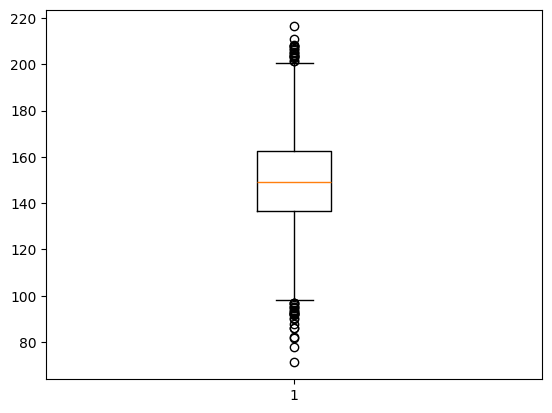

In [229]:
plt.boxplot(data['Max_Heart_Rate'])
plt.show()

In [230]:
data = data[(data['Max_Heart_Rate']>= 98) & (data['Max_Heart_Rate']<=206)]

In [231]:
data

,Age,Cholesterol,Max_Heart_Rate,Blood_Pressure,Gender,Old_Peak,Heart_Disease
0,67,171.60,138.6,116.6,0,1.69,0
1,57,250.10,197.6,114.4,0,0.47,0
2,51,171.00,149.1,117.6,1,1.12,0
3,71,293.40,129.8,147.2,0,0.21,1
4,36,220.55,105.4,130.4,1,0.22,0
...,...,...,...,...,...,...,...
2260,74,197.40,150.9,131.8,0,0.02,1
2262,63,220.55,144.6,120.9,1,2.72,1
2263,71,218.00,142.8,149.4,0,1.63,1
2264,50,199.80,149.1,142.8,0,3.02,1


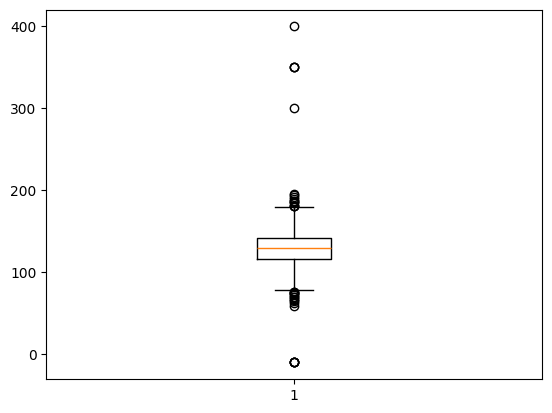

In [232]:
plt.boxplot(data['Blood_Pressure'])
plt.show()

In [233]:
q1 = data['Blood_Pressure'].quantile(0.25)
q3 = data['Blood_Pressure'].quantile(0.75)
q1,q2

(np.float64(116.7), 220.55)

In [234]:
iqr = q3 - q1
iqr

np.float64(25.39999999999999)

In [235]:
q_min = q1 - 1.5 * iqr
q_max = q3 + 1.5 * iqr

In [236]:
data = data[(data['Blood_Pressure'] >= q_min) &(data['Blood_Pressure'] <= q_max)]

In [237]:
data

,Age,Cholesterol,Max_Heart_Rate,Blood_Pressure,Gender,Old_Peak,Heart_Disease
0,67,171.60,138.6,116.6,0,1.69,0
1,57,250.10,197.6,114.4,0,0.47,0
2,51,171.00,149.1,117.6,1,1.12,0
3,71,293.40,129.8,147.2,0,0.21,1
4,36,220.55,105.4,130.4,1,0.22,0
...,...,...,...,...,...,...,...
2260,74,197.40,150.9,131.8,0,0.02,1
2262,63,220.55,144.6,120.9,1,2.72,1
2263,71,218.00,142.8,149.4,0,1.63,1
2264,50,199.80,149.1,142.8,0,3.02,1


In [238]:
q1 = data['Old_Peak'].quantile(0.25)
q3 = data['Old_Peak'].quantile(0.75)
q1,q2

(np.float64(0.5974999999999999), 220.55)

In [239]:
iqr = q3 - q1
iqr

np.float64(1.1725)

In [240]:
q_min = q1 - 1.5 * iqr
q_max = q3 + 1.5 * iqr

In [241]:
data = data[(data['Old_Peak'] >= q_min) &(data['Old_Peak'] <= q_max)]

In [242]:
data

,Age,Cholesterol,Max_Heart_Rate,Blood_Pressure,Gender,Old_Peak,Heart_Disease
0,67,171.60,138.6,116.6,0,1.69,0
1,57,250.10,197.6,114.4,0,0.47,0
2,51,171.00,149.1,117.6,1,1.12,0
3,71,293.40,129.8,147.2,0,0.21,1
4,36,220.55,105.4,130.4,1,0.22,0
...,...,...,...,...,...,...,...
2260,74,197.40,150.9,131.8,0,0.02,1
2262,63,220.55,144.6,120.9,1,2.72,1
2263,71,218.00,142.8,149.4,0,1.63,1
2264,50,199.80,149.1,142.8,0,3.02,1


In [243]:
print(data.to_csv('heart_disease_cleaned.csv'))

None


In [244]:
# from google.colab import files

# files.download("heart_disease_cleaned.csv")

In [245]:
data['Heart_Disease'].unique()

array([0, 1])

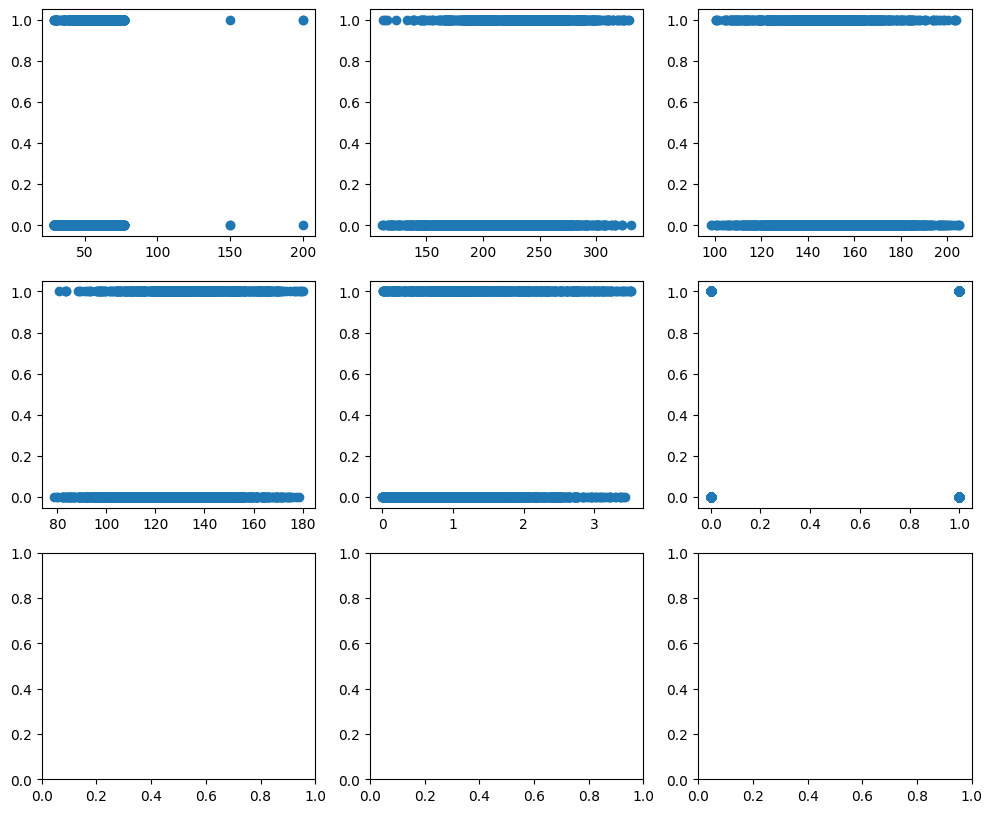

In [246]:
import matplotlib.pyplot as plt
fig,g = plt.subplots(3,3,figsize=(12, 10))
g[0,0].scatter(data['Age'],data['Heart_Disease'])
g[0,1].scatter(data['Cholesterol'],data['Heart_Disease'])
g[0,2].scatter(data['Max_Heart_Rate'],data['Heart_Disease'])
g[1,0].scatter(data['Blood_Pressure'],data['Heart_Disease'])
g[1,1].scatter(data['Old_Peak'],data['Heart_Disease'])
g[1,2].scatter(data['Gender'],data['Heart_Disease'])
plt.show()


In [247]:
import seaborn as sns

<Axes: >

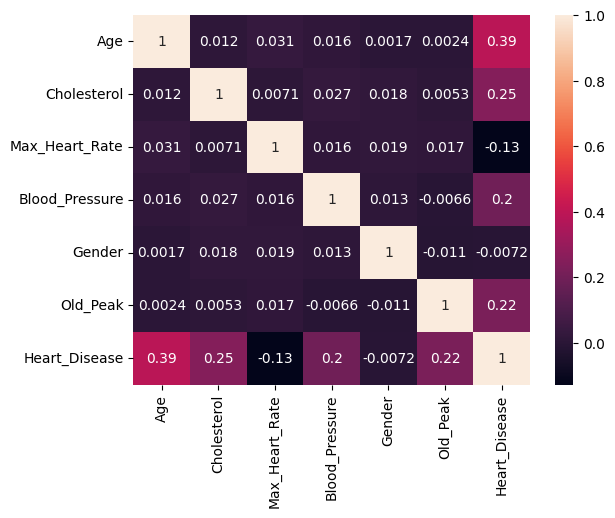

In [248]:
sns.heatmap(data.corr(),annot= True)

In [249]:
data.columns

Index(['Age', 'Cholesterol', 'Max_Heart_Rate', 'Blood_Pressure', 'Gender',
       'Old_Peak', 'Heart_Disease'],
      dtype='object')

In [250]:
x = data[['Age', 'Cholesterol', 'Max_Heart_Rate', 'Blood_Pressure','Old_Peak']]

In [251]:
x

,Age,Cholesterol,Max_Heart_Rate,Blood_Pressure,Old_Peak
0,67,171.60,138.6,116.6,1.69
1,57,250.10,197.6,114.4,0.47
2,51,171.00,149.1,117.6,1.12
3,71,293.40,129.8,147.2,0.21
4,36,220.55,105.4,130.4,0.22
...,...,...,...,...,...
2260,74,197.40,150.9,131.8,0.02
2262,63,220.55,144.6,120.9,2.72
2263,71,218.00,142.8,149.4,1.63
2264,50,199.80,149.1,142.8,3.02


In [252]:
y = data['Heart_Disease']

In [253]:
y

,Heart_Disease
0,0
1,0
2,0
3,1
4,0
...,...
2260,1
2262,1
2263,1
2264,1


In [254]:
from sklearn.model_selection import train_test_split

In [255]:
x_tarin,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [256]:
from sklearn.linear_model import LogisticRegression

In [257]:
from sklearn.neighbors import KNeighborsClassifier

In [268]:
from sklearn.svm import SVC

In [258]:
from xgboost import XGBClassifier

In [269]:
# model = LogisticRegression()
# model = KNeighborsClassifier(n_neighbors=7)
# model = XGBClassifier(n_estimators=100)
model = SVC(kernel='linear',C=1)


In [270]:
model

SVC(C=1, kernel='linear')

In [271]:
model.fit(x_tarin,y_train)

SVC(C=1, kernel='linear')

In [272]:
output = model.predict([[60,167,159,178,2.3]])
output

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([1])

In [273]:
from sklearn.metrics import classification_report

In [274]:
train_pred = model.predict(x_tarin)
train_pred

array([0, 0, 1, ..., 0, 0, 0])

In [275]:
report = classification_report(y_train,train_pred)
print(report)

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       956
           1       0.73      0.66      0.69       530

    accuracy                           0.79      1486
   macro avg       0.77      0.76      0.77      1486
weighted avg       0.79      0.79      0.79      1486



In [276]:
test_pred = model.predict(x_test)
test_pred

array([0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,

In [277]:
report = classification_report(y_test,test_pred)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       423
           1       0.70      0.70      0.70       214

    accuracy                           0.80       637
   macro avg       0.78      0.78      0.78       637
weighted avg       0.80      0.80      0.80       637

